In [68]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import calendar
import folium
import matplotlib.cm as cm
import matplotlib.colors
import pytz
import os

#### **The LLUDA GPS loggers capture:**
- **Date**: MM/DD/YYYY
- **Time**: HH:MM:SS in UTC
- **Latitude**: DDMM.MMMM
- **Longitude**: DDDMM.MMMM
- **Altitude**: Measured in meters (m)
- **Speed**: Measured in meters per second (m/s)

In [ ]:
def convert_utc_to_local_timezone(data, fleet_timezone):
    data['Month'] = data['Date'].str.split('/').str[0].astype(int)
    data = data[data['Month'] <= 12].copy()
    data['Datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'].str.strip(), format='%m/%d/%Y %H:%M:%S', errors='coerce')
    data.drop(columns='Month', inplace=True)
        
    data['Datetime'] = pd.to_datetime(data['Datetime'], errors='coerce')
    data[fleet_timezone + ' Datetime'] = data['Datetime'].dt.tz_localize('UTC').dt.tz_convert(fleet_timezone)
    data.sort_values(by=[fleet_timezone + ' Datetime'], inplace=True)

    data[fleet_timezone + ' Date'] = data[fleet_timezone + ' Datetime'].dt.strftime('%Y-%m-%d')
    data[fleet_timezone + ' Time'] = data[fleet_timezone + ' Datetime'].dt.strftime('%H:%M:%S')
    data[fleet_timezone + ' Hour'] = data[fleet_timezone + ' Datetime'].dt.hour
    data[fleet_timezone + ' Minute'] = data[fleet_timezone + ' Datetime'].dt.minute
    data[fleet_timezone + ' Second'] = data[fleet_timezone + ' Datetime'].dt.second
    
    return data

def plot_speed_comparison(date_df):
    filename = date_df['Filename'].iloc[0]
    # Before filtering
    print('Before filtering raw GPS speed:')
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_facecolor('#eeeeee')
    plt.plot(date_df['Speed (m/s)'] * 2.237, label='Raw Speed [$MPH$]', color='#0076b6')
    plt.xlabel('Datapoint', fontsize=11)
    plt.ylabel('Raw Speed [$MPH$]', fontsize=11)
    plt.tick_params(axis='both', which='major', labelsize=11)
    plt.title(filename, fontsize=11)
    plt.ylim(-0.5, None)
    plt.xlim(0, None)
    plt.grid(True, color='white')
    plt.legend(facecolor='#eeeeee', loc='upper right', fontsize=11)
    plt.show()
    
    # After filtering
    print('After filtering raw GPS speed:')
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_facecolor('#eeeeee')
    plt.plot(date_df['Filtered Speed (MPH)'], label='Filtered Speed [$MPH$]', color='#74a12e')
    plt.xlabel('Datapoint', fontsize=11)
    plt.ylabel('Filtered Speed [$MPH$]', fontsize=11)
    plt.tick_params(axis='both', which='major', labelsize=11)
    plt.title(filename, fontsize=11)
    plt.ylim(0, None)
    plt.xlim(0, None)
    plt.grid(True, color='white')
    plt.legend(facecolor='#eeeeee', loc='upper right', fontsize=11)
    plt.show()

def get_indices_binning(lst, num, min_count, max_count):
    # Find sequences of a specific number within specified count ranges.
    sequences = []
    start_index = None
    num_count = 0

    for i in range(len(lst)):
        if lst[i] == num:
            # Start or continue counting sequence
            if start_index is None:
                start_index = i
            num_count += 1
        else:
            # End of sequence - check if it meets criteria
            if start_index is not None and min_count <= num_count <= max_count:
                sequences.append([start_index, i - 1])
            # Reset for next sequence
            start_index = None
            num_count = 0

    # Check final sequence at end of array
    if start_index is not None and min_count <= num_count <= max_count:
        sequences.append([start_index, len(lst) - 1])

    return sequences if sequences else None
        
def trip_stats_calc(data, fleet_timezone):
    outputs = {}
    outputs['Vehicle ID'] = data['Vehicle ID'].iloc[0]
    outputs['Filename'] = data['Filename'].iloc[0]
    
    outputs[fleet_timezone + ' Date'] = data[fleet_timezone + ' Date'].iloc[0]
    outputs['Month'] = data['Month'].iloc[0]
    
    outputs[fleet_timezone + ' Start Time'] = data[fleet_timezone + ' Time'].iloc[0]
    outputs[fleet_timezone + ' End Time'] = data[fleet_timezone + ' Time'].iloc[-1]
    
    dt = 1 # Second by second data
    speed_kph = data['Filtered Speed (km/hr)'].values
    
    # Distance calculations
    outputs['distance_km'] = np.round(np.sum(speed_kph / 3600.0 * dt), 3)
    outputs['distance_mi'] = np.round(outputs['distance_km'] / 1.609, 3)
    
    # Speed calculations
    outputs['average_speed_mph'] = np.round(np.mean(speed_kph) / 1.609, 3)
    moving_mask = speed_kph > 0
    if moving_mask.any():
        outputs['average_driving_speed_mph'] = np.round(np.mean(speed_kph[moving_mask]) / 1.609, 3)
        outputs['hrs_moving'] = np.round(np.sum(moving_mask) * dt / 3600.0, 3)
    else:
        outputs['average_driving_speed_mph'] = np.nan
        outputs['hrs_moving'] = np.nan
    
    outputs['average_speed_kph'] = np.round(outputs['average_speed_mph'] * 1.609, 3)
    outputs['average_driving_speed_kph'] = np.round(outputs['average_driving_speed_mph'] * 1.609, 3)
    
    # Method 1 for idle hours (whenever speed is 0)
    idle_mask = speed_kph == 0
    outputs['idle_hrs_method1'] = np.round(np.sum(idle_mask) * dt / 3600.0, 3)
    
    # Method 2 for idle hours (whenever speed is 0 for 45 seconds to 5 minutes)
    idle_bins = get_indices_binning(speed_kph, 0, 45, 300)
    if idle_bins:
        idle_durations = [np.diff(pair)[0] for pair in idle_bins]
        outputs['idle_hrs_method2'] = np.round(np.sum(idle_durations) / 3600.0, 3)
    else:
        outputs['idle_hrs_method2'] = 0
    
    outputs['hrs_logging'] = np.round(len(speed_kph) * dt / 3600.0, 3)
    
    return outputs

def map_trips_by_veh_id(date_dfs, fleet_type, fleet_timezone, parent_dir, veh_stats_df, display_map=False):
    for veh_id, dfs in date_dfs.items():
        if not dfs:
            continue
        
        center_lat = dfs[0]['Latitude'].mean()
        center_lon = dfs[0]['Longitude'].mean()
        map_obj = folium.Map(location=[center_lat, center_lon], zoom_start=10, control_scale=True)

        folium.TileLayer(
            tiles='https://mt1.google.com/vt/lyrs=r&x={x}&y={y}&z={z}',
            attr='Google Maps',
            name='Google Maps',
            overlay=True,
            control=True
        ).add_to(map_obj)
        
        map_features = []
        for t, df in enumerate(dfs):
            # Only map files that are in vehicle statistics (vehicle must travel at least 1 mile)
            if df['Filename'].iloc[0] in veh_stats_df['Filename'].tolist():
                trip_date = f"{fleet_type}_{veh_id}: {df[fleet_timezone + ' Date'].iloc[0]}"
                
                trip_subgroup = folium.FeatureGroup(name=trip_date)
                color = matplotlib.colors.to_hex(cm.tab20b(t % 20))
                
                # Filter noisy GPS points
                lat_diff = df['Latitude'].diff().abs()
                lon_diff = df['Longitude'].diff().abs()
                
                jump_indices = np.where((lat_diff > 0.001373) | (lon_diff > 0.001373))[0].tolist()
                jump_indices = [0] + jump_indices + [len(df) - 1]
                jump_indices = sorted(set(jump_indices))
                
                for i in range(1, len(jump_indices)):
                    start_idx = jump_indices[i-1]
                    end_idx = jump_indices[i]
                    sub_df = df.iloc[start_idx:end_idx]
                    
                    if len(sub_df) > 1:
                        coordinates = list(zip(sub_df['Latitude'], sub_df['Longitude']))
                        folium.PolyLine(
                            locations=coordinates,
                            weight=4,
                            color=color
                        ).add_to(trip_subgroup)
                
                map_features.append(trip_subgroup)

        for feature in map_features:
            map_obj.add_child(feature)
        
        map_obj.add_child(folium.LayerControl())
        map_obj.add_child(folium.LatLngPopup())
        
        # Save map
        daily_folder = f'{fleet_type}_{veh_id}_Daily'
        daily_folder_path = os.path.join(parent_dir, daily_folder)
        if os.path.exists(daily_folder_path):
            map_filename = f'{fleet_type}_{veh_id}_Map.html'
            map_path = os.path.join(daily_folder_path, map_filename)
            map_obj.save(map_path)
            
            if display_map:
                display(map_obj)

def combine_and_parse_by_date(parent_dir, fleet_type, fleet_timezone, file_location, vehicles_to_exclude=None, disp_speed=False):
    """
    Process 1 Hz GPS data from LLUDA loggers by combining each unique logger or vehicle ID and parsing by unique date.

    Args:
        parent_dir: Parent directory containing vehicle folders
        fleet_type: Type of fleet (string identifier)
        fleet_timezone: Local timezone for the fleet (e.g., 'US/Pacific')
        file_location: Location to save output files
        vehicles_to_exclude: List of vehicle IDs to exclude (default -- empty list or None)
        disp_speed: Whether to display speed plots (default: False)
        
    Returns:
        dict: Contains veh_stats_df, date_dfs, and brief_stats
    """
    if vehicles_to_exclude is None:
        vehicles_to_exclude = []
    
    all_items = os.listdir(parent_dir)
    veh_folders = [x for x in all_items if not any(exclude in x for exclude in ['Daily'] + vehicles_to_exclude)]

    total_files = 0
    for veh_folder in veh_folders:
        folder_path = os.path.join(parent_dir, veh_folder)
        if os.path.isdir(folder_path):
            total_files += len(glob.glob(os.path.join(folder_path, '**', '*.csv'), recursive=True))
    
    outputs = []
    date_dfs = {}
    processed_files = 0
    for veh_folder in veh_folders:
        folder_path = os.path.join(parent_dir, veh_folder)
        if not os.path.isdir(folder_path):
            continue
            
        all_files = os.listdir(folder_path)
        # Handle both .csv and .CSV file extensions
        csv_files = [f for f in all_files if (f.endswith('.csv') or f.endswith('.CSV')) and 'Merged' not in f]
        
        merged_filename = f'Merged_{veh_folder}.csv'
        if merged_filename in all_files:
            print(f'Merged file already exists for {veh_folder}. Skipping!')
            continue
        
        dfs = []
        veh_id = veh_folder.split('_')[1] if '_' in veh_folder else veh_folder
        
        for csv_file in csv_files:
            processed_files += 1
                
            file_path = os.path.join(folder_path, csv_file)
            
            try:
                data = pd.read_csv(file_path)
            except Exception as e:
                print(f'Error reading {csv_file}: {e}')
                continue

            if data.empty or all(col.strip() == '' for col in data.columns):
                continue

            if 'Date' not in data.columns:
                data.columns = ['Date', 'Time', 'Latitude', 'Longitude', 'Altitude (m)', 'Speed (m/s)']
            
            data['Vehicle ID'] = veh_id
            
            # Convert to local timezone of fleet
            data = convert_utc_to_local_timezone(data, fleet_timezone)
            data = data.drop_duplicates(subset=[fleet_timezone + ' Datetime'])
            data = data.sort_values(by=fleet_timezone + ' Datetime').reset_index(drop=True)
            
            dfs.append(data)
        
        # Process concatenated data for this vehicle
        date_dfs[veh_id] = []
        if dfs:
            merged_data = pd.concat(dfs, ignore_index=True)
            merged_data = merged_data.sort_values(by=fleet_timezone + ' Datetime')
            merged_path = os.path.join(folder_path, merged_filename)
            merged_data.to_csv(merged_path, index=False)
            
            # Group by date and process each day
            date_groups = merged_data.groupby(fleet_timezone + ' Date')
            
            for date, date_df in date_groups:
                if pd.isna(date):
                    continue
                
                date_df = date_df.copy()
                date_df['Filename'] = f'{fleet_type}_{veh_id}_{date}.csv'
                
                date_df[fleet_timezone + ' Datetime'] = pd.to_datetime(date_df[fleet_timezone + ' Datetime'])
                date_df = date_df.sort_values(by=fleet_timezone + ' Datetime').reset_index(drop=True)
                date_df[fleet_timezone + ' Date'] = date_df[fleet_timezone + ' Datetime'].dt.strftime('%Y-%m-%d')
                date_df['Month'] = date_df[fleet_timezone + ' Datetime'].dt.month

                dt_diff = date_df[fleet_timezone + ' Datetime'].diff()
                date_df['Delta Time (sec)'] = dt_diff.dt.total_seconds()
                
                # Filter raw GPS speed
                speed_raw = date_df['Speed (m/s)'].values
                speed_filtered = np.where(speed_raw <= 38, np.where(speed_raw <= 0.3, 0, speed_raw), speed_raw) # m/s; update as needed based on fleet characteristics
                date_df['Filtered Speed (m/s)'] = speed_filtered
                date_df['Filtered Speed (km/hr)'] = date_df['Filtered Speed (m/s)'] * 3.6
                date_df['Filtered Speed (MPH)'] = date_df['Filtered Speed (m/s)'] * 2.237
                
                # Display speed plots if requested
                if disp_speed:
                    plot_speed_comparison(date_df)

                # Calculate trip statistics
                output = trip_stats_calc(date_df, fleet_timezone)
                if output['distance_mi'] >= 1: # Vehicle must travel at least 1 mile
                    outputs.append(output)
                
                # Save daily file
                if len(date_df) > 0:
                    output_directory = os.path.join(parent_dir, f'{fleet_type}_{veh_id}_Daily')
                    os.makedirs(output_directory, exist_ok=True)
                    daily_file_path = os.path.join(output_directory, date_df['Filename'].iloc[0])
                    date_df.to_csv(daily_file_path, index=False)
                    
                    date_dfs[veh_id].append(date_df)

    veh_stats_df = pd.DataFrame(outputs)
    today_date = datetime.today().strftime('%Y-%m-%d')
    stats_filename = f'{fleet_type}_Veh_Stats_Processed_{today_date}.csv'
    stats_path = os.path.join(file_location, stats_filename)
    veh_stats_df.to_csv(stats_path, index=False)
    
    # Create brief statistics
    if not veh_stats_df.empty:
        brief_stats = pd.DataFrame({
            'Vehicle Count': [len(veh_stats_df['Vehicle ID'].unique())],
            'Calendar Days': [len(veh_stats_df[fleet_timezone + ' Date'].unique())],
            'Vehicle Days': [len(veh_stats_df)],
            'Unique Months': [', '.join([calendar.month_name[m] for m in sorted(veh_stats_df['Month'].unique())])],
            'Miles of Data': [int(veh_stats_df['distance_mi'].sum())],
            'Kilometers of Data': [int(veh_stats_df['distance_km'].sum())],
            'Hours Moving': [int(veh_stats_df['hrs_moving'].sum())]})
    else:
        brief_stats = pd.DataFrame()
    
    return {
        'veh_stats_df': veh_stats_df,
        'date_dfs': date_dfs,
        'brief_stats': brief_stats}

In [70]:
print('Commonly used time-zones:', pytz.common_timezones, '\n') # Options for fleet_timezone argument

Commonly used time-zones: ['Africa/Abidjan', 'Africa/Accra', 'Africa/Addis_Ababa', 'Africa/Algiers', 'Africa/Asmara', 'Africa/Bamako', 'Africa/Bangui', 'Africa/Banjul', 'Africa/Bissau', 'Africa/Blantyre', 'Africa/Brazzaville', 'Africa/Bujumbura', 'Africa/Cairo', 'Africa/Casablanca', 'Africa/Ceuta', 'Africa/Conakry', 'Africa/Dakar', 'Africa/Dar_es_Salaam', 'Africa/Djibouti', 'Africa/Douala', 'Africa/El_Aaiun', 'Africa/Freetown', 'Africa/Gaborone', 'Africa/Harare', 'Africa/Johannesburg', 'Africa/Juba', 'Africa/Kampala', 'Africa/Khartoum', 'Africa/Kigali', 'Africa/Kinshasa', 'Africa/Lagos', 'Africa/Libreville', 'Africa/Lome', 'Africa/Luanda', 'Africa/Lubumbashi', 'Africa/Lusaka', 'Africa/Malabo', 'Africa/Maputo', 'Africa/Maseru', 'Africa/Mbabane', 'Africa/Mogadishu', 'Africa/Monrovia', 'Africa/Nairobi', 'Africa/Ndjamena', 'Africa/Niamey', 'Africa/Nouakchott', 'Africa/Ouagadougou', 'Africa/Porto-Novo', 'Africa/Sao_Tome', 'Africa/Tripoli', 'Africa/Tunis', 'Africa/Windhoek', 'America/Adak', 

Before filtering raw GPS speed:


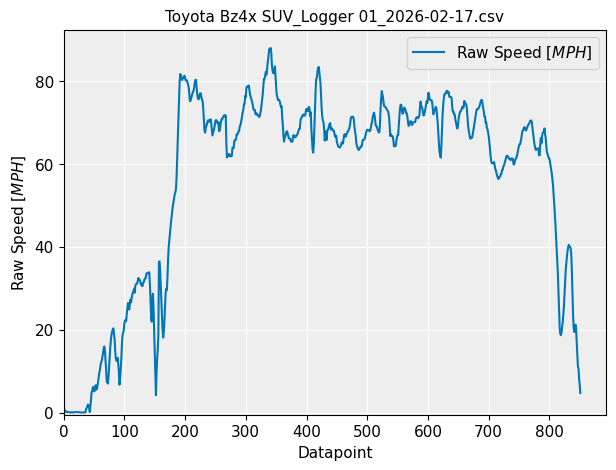

After filtering raw GPS speed:


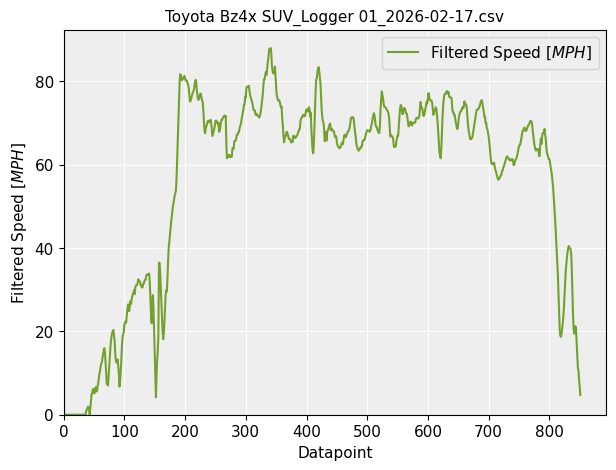

In [71]:
results = combine_and_parse_by_date(
    parent_dir=r"C:\Users\sfakhimi\Desktop\Projects\Seattle Ports\Testing LLUDA GPS Loggers", # Directory containing vehicle folders with raw GPS CSV files
    fleet_type='Toyota Bz4x SUV', # Fleet identifier string used for output file naming
    fleet_timezone='America/Denver', # Local timezone for converting UTC timestamps to local time
    file_location=r"C:\Users\sfakhimi\Desktop\Projects\Seattle Ports\Testing LLUDA GPS Loggers\Toyota Bz4x SUV_Logger 01_Daily", # Directory where final statistics CSV will be saved
    vehicles_to_exclude=None, # List of vehicle IDs to skip (None means include all vehicles)
    disp_speed=True)  

In [72]:
vehicle_stats = results['veh_stats_df']
daily_data = results['date_dfs'] 
summary = results['brief_stats']
display(vehicle_stats)
display(summary)

,Vehicle ID,Filename,America/Denver Date,Month,America/Denver Start Time,America/Denver End Time,distance_km,distance_mi,average_speed_mph,average_driving_speed_mph,hrs_moving,average_speed_kph,average_driving_speed_kph,idle_hrs_method1,idle_hrs_method2,hrs_logging
0,Logger 01,Toyota Bz4x SUV_Logger 01_2026-02-17.csv,2026-02-17,2,10:43:01,10:57:13,21.476,13.347,56.399,59.031,0.226,90.746,94.981,0.011,0,0.237


,Vehicle Count,Calendar Days,Vehicle Days,Unique Months,Miles of Data,Kilometers of Data,Hours Moving
0,1,1,1,February,13,21,0


In [ ]:
# Create maps for each vehicle showing daily trips
map_trips_by_veh_id(
    date_dfs=results['date_dfs'], # Dictionary of daily GPS dataframes organized by vehicle ID
    fleet_type='Toyota Bz4x SUV', # Fleet name used for map titles and file naming
    fleet_timezone='America/Denver', # Timezone string for extracting date columns from dataframes
    parent_dir=r"C:\Users\sfakhimi\Desktop\Projects\Seattle Ports\Testing LLUDA GPS Loggers", # Base directory where daily vehicle folders exist for saving map HTML files
    veh_stats_df=results['veh_stats_df'], # Vehicle statistics dataframe to filter which trips to map (≥1 mile criterion)
    display_map=False)